# Faza 3: NLP obdelava besedilnih polj in ocena tveganja

**Zastavljen cilj**: Ker tradicionalni finančni podatki pogosto ne zadostujejo za polno sliko, smo želeli iz polarnosti prosilčevih besed (`desc`) in statusa poklica (`emp_title`) dodatno izluščiti indikatorje rizika. Tekstovne vnose smo zato transformirali v numerične vektorje na podlagi frekvenc besed in semantične ocene z umentno inteligenco.

Dokument sledi standardizirani obliki poročila (pretekli čas), programska implementacija je prepuščena ekipi.

## 1. Uvoz knjižnic in podatkov iz 2. faze

Najprej smo naložili t.i. "selected" verzijo analiziranih baz (učna in testna množica), ki so že bile zdesetkane v dimenzionalnosti zavoljo pomembnih numeričnih značilk, a so ohranile obe izvirni besedilni polji.

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
import transformers
import re
from transformers import pipeline

# TODO (ekipa): Naloži prečiščene tabele: `../data/train_selected.csv` in `../data/test_selected.csv`.
# TODO (ekipa): Preglej tekstovna polja (izpiši nekaj specifičnih primerov zapisov v `desc` in `emp_title`).

train_df = pd.read_csv("../data/train_selected.csv")
test_df = pd.read_csv("../data/test_selected.csv")

# Pregled tekstovnih polj
print("Primeri nazivov (emp_title):")
print(train_df['emp_title'].dropna().head(3).tolist())
print("\nPrimeri opisov (desc):")
print(train_df['desc'].dropna().head(3).tolist())

Primeri nazivov (emp_title):
['Cooley Dickinson Hospital', 'Application Support Team Lead', 'Forman']

Primeri opisov (desc):
['  Borrower added on 01/19/13 > to pay off high interest credit cards and home repairs<br>', '  Borrower added on 03/07/13 > To pay off credit card and signature loan<br><br>  Borrower added on 03/07/13 > My credit worthiness is among the very best and want to reduce my indebtedness with this loan<br><br> Borrower added on 03/07/13 > To payoff credit card debt as I said before<br>', '  Borrower added on 12/28/12 > Consolidate all credit card debt into one more manageable payment and start saving money.<br>']


## 2. Modeliranje terminologije zaposlitvenih nazivov (TF-IDF)

Kratki naslovi poklicev (npr. *"Manager"*, *"Teacher"*, *"RN"*) posredno nosijo močan signal prihodkovnega potenciala in s tem finančne stabilnosti stranke.

1. Besedilo smo standardizirali, odstranili posebne znake in oštevilčenja.
2. Skonstruirali smo algoritem `TfidfVectorizer`, ga naučili na **učnih** podatkih na vrhunskih Top N (npr. 50) pogostih termov in ga hkrati uporabili tudi na **testnih** podatkih.
3. Nastalo matriko frekvenc smo dodali tabeli.

In [2]:
# TODO (ekipa): Naredi enostavno čiščenje `emp_title` (črke v str.lower(), odstranitev simbolov).
# TODO (ekipa): Inicializiraj `TfidfVectorizer(max_features=50, stop_words='english')` in ga uči (.fit) SAMO na train podatkih.
# TODO (ekipa): Transformiraj tekst obeh množic v TF matriko. Pretobi matriko v pd.DataFrame z ustreznimi imeni stolpcev (npr. 'tfidf_emp_manager') in jih stakni z osnovno tabelo.

def clean_text(text):
    if pd.isna(text) or str(text) == "nan" or str(text) == "unknown":
        return ""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)  # Ohranimo le črke in presledke
    return text.strip()

train_df['emp_title_clean'] = train_df['emp_title'].apply(clean_text)
test_df['emp_title_clean'] = test_df['emp_title'].apply(clean_text)

# Inicializiraj `TfidfVectorizer` (najboljših 50 besed, brez mašil) in ga uči SAMO na train podatkih
vectorizer = TfidfVectorizer(max_features=50, stop_words='english')
tfidf_train = vectorizer.fit_transform(train_df['emp_title_clean'])
tfidf_test = vectorizer.transform(test_df['emp_title_clean'])

# Transformiraj tekst obeh množic v TF matriko pd.DataFrame
feature_names = [f"tfidf_emp_{word}" for word in vectorizer.get_feature_names_out()]

df_tfidf_train = pd.DataFrame(tfidf_train.toarray(), columns=feature_names, index=train_df.index)
df_tfidf_test = pd.DataFrame(tfidf_test.toarray(), columns=feature_names, index=test_df.index)

# Združi matriki in odstrani pomožne stolpce
train_df = pd.concat([train_df, df_tfidf_train], axis=1)
test_df = pd.concat([test_df, df_tfidf_test], axis=1)

train_df = train_df.drop(columns=['emp_title_clean'])
test_df = test_df.drop(columns=['emp_title_clean'])

print("Uspešno dodani TF-IDF stolpci:", len(feature_names))

Uspešno dodani TF-IDF stolpci: 50


## 3. Analiza sentimenta v opisu posojila (HuggingFace)

Posamezniki občasno specificirajo razloge za kredite, ki lahko kažejo na optimizem ali pa na očitno in drago preživetveno konsolidacijo z drugimi posojili. V tem koraku smo uporabili predhodno učenje Transformerje (`pipeline("sentiment-analysis")`).

Za vsako vrstico smo izračunali verjetnost negativno polarizirane izjave in s tem ocenili posameznikov opis ter rezultat zabeležili pod `desc_sentiment_score` zveznega formata. Kjer opisa znotraj originalne baze ni bilo (prazna polja), smo uveljavili preprosto sredinjsko (nevtralno) vrednost.

In [3]:
# TODO (ekipa): Inicializirajte NLP pipeline za klasifikacijo. Lahko vzamete npr. defaultni DistilBERT ali robustnejši FinBERT `pipeline('sentiment-analysis', model='yiyanghkust/finbert-tone')`.
# TODO (ekipa): Napišite funkcijo, ki za vstavek vrne pozitiven ali negativen score [0, 1]. Če je `desc` prazen (""), vrnite nevtralni score (0.5).
# TODO (ekipa): Uporabite pandas .apply() oz. batch preprocesiranje na `desc` stolpcu obeh podružnic tabele in izdelek shranite v `desc_sentiment_score` zgneten z osnovno množico.

# Inicializirajte NLP pipeline za klasifikacijo sentimenta
sentiment_pipeline = pipeline('sentiment-analysis')

def get_sentiment_score(text):
    text_str = str(text).strip()
    if pd.isna(text) or text_str == "" or text_str == "nan":
        return 0.5  # Nevtralno
    
    # Skrajšamo besedilo na max dopustno dolžino zaradi pospešitve
    short_text = text_str[:500] 
    try:
        res = sentiment_pipeline(short_text)[0]
        # Želimo negativen pol (večje kot je stevilo, vecji je strah za default)
        if res['label'] == 'NEGATIVE':
            return res['score'] 
        else:
            return 1.0 - res['score']
    except:
        return 0.5

print("Ocenjujem opisni sentiment na učni množici (počakajte)...")
train_df['desc_sentiment_score'] = train_df['desc'].apply(get_sentiment_score)

print("Ocenjujem opisni sentiment na testni množici (počakajte)...")
test_df['desc_sentiment_score'] = test_df['desc'].apply(get_sentiment_score)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Ocenjujem opisni sentiment na učni množici (počakajte)...
Ocenjujem opisni sentiment na testni množici (počakajte)...


## 4. Zaključek formiranja podatkov

Iz podatkov smo zbrisali prvotne tekstualne različice in tako zapečatili razvoj. Obe podatkovni množici smo spravili v direktorij `data/` za uporabo v algoritmih strojnega učenja.

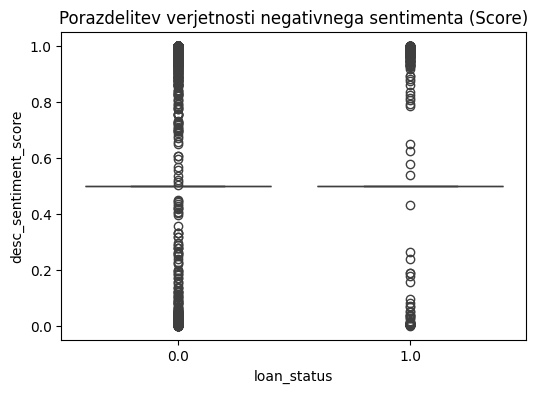

Število manjkajočih vrednosti v ciljni Train bazi: 0
Število manjkajočih vrednosti v ciljni Test bazi: 0

[✔] Popolnoma prečiščeni numerični in NLP podatki pripravljeni za klasifikacijo prenešeni v train_final in test_final.


In [4]:
# TODO (ekipa): Opcijsko vizualizirajte korelacijo med vašim `desc_sentiment_score` in `loan_status`.
# TODO (ekipa): Odstranite in zavrzite preostanek prvotnega tekstovnega besedila (`desc`, `emp_title`). 
# TODO (ekipa): Preverite prisotnost NaNs v združenih df. Shranite finaliziran produkt kot `../data/train_final.csv` in `../data/test_final.csv`.

import matplotlib.pyplot as plt
import seaborn as sns
import os

# Pokažemo korelacijo sentimenta glede na loan status
target_col = [col for col in train_df.columns if 'loan_status' in col.lower()][0]

plt.figure(figsize=(6,4))
sns.boxplot(x=target_col, y='desc_sentiment_score', data=train_df)
plt.title("Porazdelitev verjetnosti negativnega sentimenta (Score)")
plt.show()

# Odstranite in zavrzite preostanek prvotnega tekstovnega besedila
train_df = train_df.drop(columns=['desc', 'emp_title'])
test_df = test_df.drop(columns=['desc', 'emp_title'])

# Preverite prisotnost NaNs v združenih df
print("Število manjkajočih vrednosti v ciljni Train bazi:", train_df.isnull().sum().sum())
print("Število manjkajočih vrednosti v ciljni Test bazi:", test_df.isnull().sum().sum())

# Shranite finaliziran produkt
os.makedirs("../data", exist_ok=True)
train_df.to_csv('../data/train_final.csv', index=False)
test_df.to_csv('../data/test_final.csv', index=False)
print("\n[✔] Popolnoma prečiščeni numerični in NLP podatki pripravljeni za klasifikacijo prenešeni v train_final in test_final.")